## NSGA-II

In [1]:
from mofgbmlpy.utility.parallel_cross_validation import run_cross_validation
from datetime import datetime

current_time = datetime.now()
time_str = current_time.strftime("%Y_%m_%d_%H_%M_%S")

In [2]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "nsga2",
    ]
    
    run_cross_validation(args, dataset_root)

Running cross-validation experiments: 100%|██████████| 30/30 [00:52<00:00,  1.76s/ experiment]


Execution time: 53.37


Running cross-validation experiments: 100%|██████████| 30/30 [03:06<00:00,  6.23s/ experiment]


Execution time: 187.22


Running cross-validation experiments: 100%|██████████| 30/30 [01:26<00:00,  2.89s/ experiment]


Execution time: 87.19


=========== DATASET iris ===========



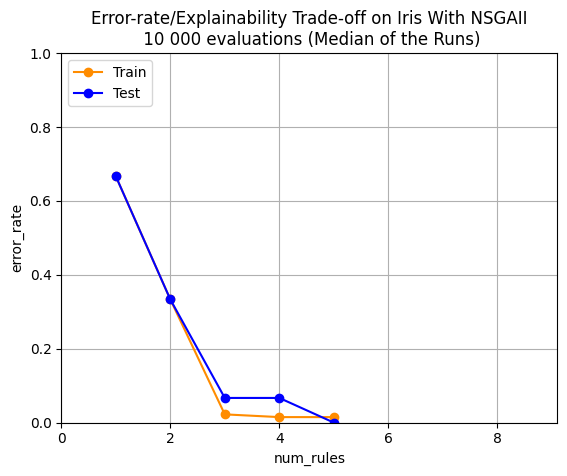

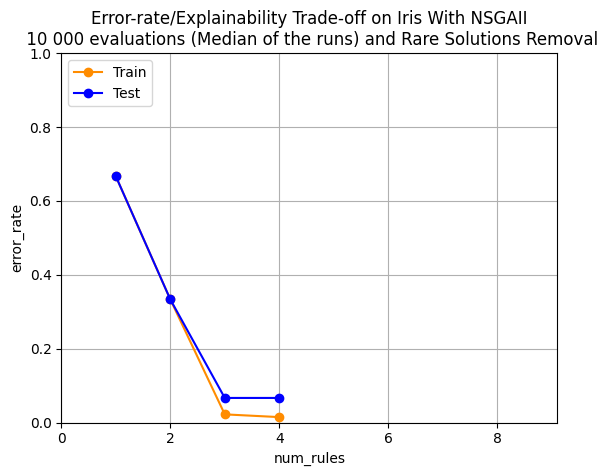

run times:
Q1:  14.591983079910278
Median :  15.165119528770447
Q3:  15.421581864356995
Average :  14.50608361562093
Std:  1.5681087775435716
=========== DATASET pima ===========



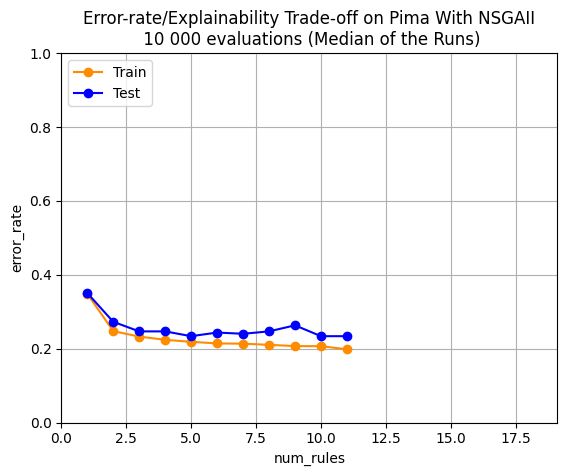

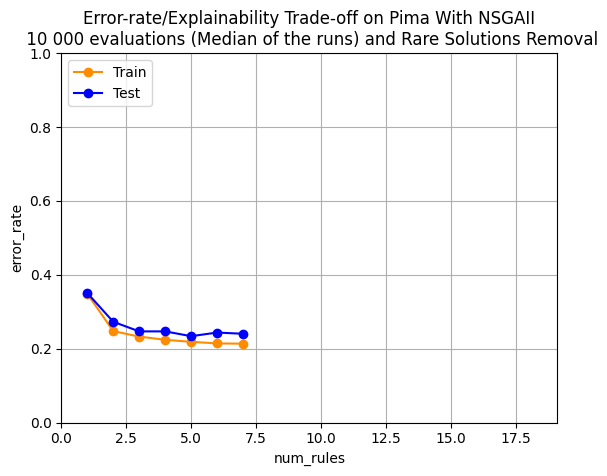

run times:
Q1:  48.73823553323746
Median :  51.69742512702942
Q3:  54.46300929784775
Average :  50.60041584173838
Std:  5.781810458342486
=========== DATASET bupa ===========



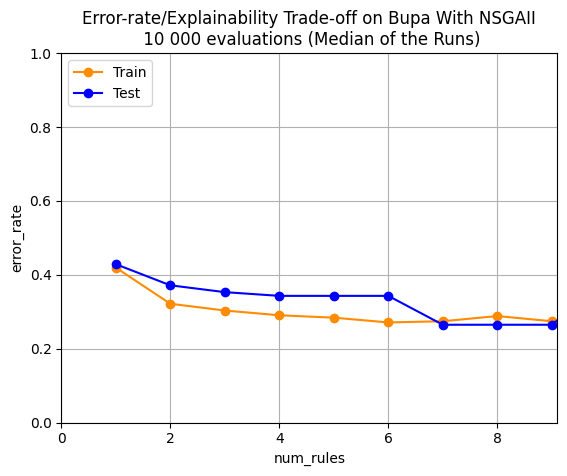

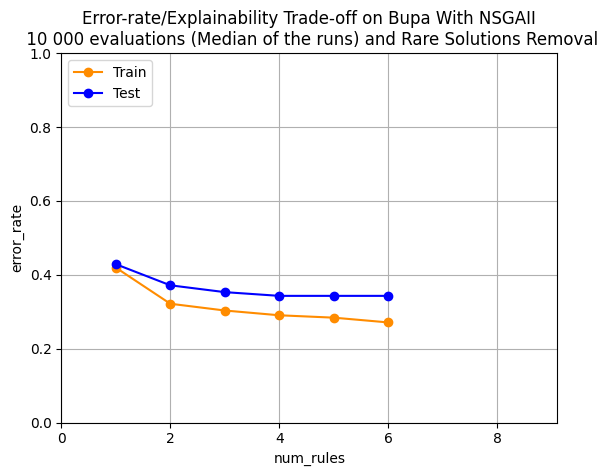

run times:
Q1:  22.132327020168304
Median :  24.1279798746109
Q3:  25.616660118103027
Average :  23.684044782320658
Std:  2.735678071534662


In [3]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,9.1),
    "pima": (0,19.1),
    "bupa": (0,9.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]
    
    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)
        
    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()
    print("run times:")
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))


## MOEA/D

In [ ]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "moead",
    ]

    run_cross_validation(args, dataset_root)

Running cross-validation experiments:  80%|████████  | 24/30 [00:45<00:03,  1.69 experiment/s]

In [ ]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,10.1),
    "pima": (0,12.1),
    "bupa": (0,11.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]

    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)

    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()

    print("run times:")
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))